# Proyecto Integrador 5.12 — Capítulo 5: Árboles e Interpretabilidad
## Notebook 1: Análisis Exploratorio de Datos (EDA)

---

**Asignatura:** Machine Learning
**Proyecto:** Predicción de Churn en Telecomunicaciones
**Dataset:** IBM Telco Customer Churn (7,043 clientes)
**Fecha:** 2025

---

### Objetivo del Notebook

Este notebook constituye la primera etapa del flujo de trabajo del proyecto. Su propósito es realizar
un análisis exploratorio riguroso del dataset *IBM Telco Customer Churn* con los siguientes objetivos específicos:

1. **Comprender la estructura del dataset:** dimensiones, tipos de variables y calidad de los datos.
2. **Detectar valores faltantes y duplicados** que requieran tratamiento previo al modelado.
3. **Analizar el desbalance de la variable objetivo** (`Churn`) para anticipar estrategias de evaluación.
4. **Identificar patrones y correlaciones** entre las variables predictoras y la probabilidad de abandono.
5. **Generar hipótesis** sobre qué variables tendrán mayor importancia en los modelos predictivos.

Los resultados de este análisis guiarán las decisiones de preprocesamiento y selección de modelos en el Notebook 2.

---


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Se importan las librerías necesarias. `pandas` y `numpy` manejan los datos en formato tabular, `matplotlib` y `seaborn` generan las visualizaciones, y `pathlib` construye rutas de archivo compatibles entre sistemas operativos. Las opciones de display se configuran para ver todas las columnas y hasta 100 filas sin truncamiento.

### 2. Carga del Dataset

Se carga el dataset original desde la carpeta `data/raw/`. La ruta se construye de forma relativa
al directorio del proyecto usando `pathlib.Path`, lo que garantiza compatibilidad entre sistemas operativos.

Se espera observar el dataset con 7,043 registros y 21 columnas, incluyendo variables demográficas,
servicios contratados, información contractual y la variable objetivo `Churn`.


In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = BASE_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


El dataset se carga con 7.043 filas y 21 columnas. Se pueden ver variables demográficas como `gender` y `SeniorCitizen`, servicios contratados como `InternetService` y `OnlineSecurity`, variables de facturación, y la variable objetivo `Churn` con valores `'Yes'` y `'No'`.

In [3]:
df.shape

(7043, 21)

El dataset tiene 7.043 registros y 21 columnas.

### 3. Calidad del Dataset

Se analiza la calidad del dataset mediante tres verificaciones fundamentales:
- **Dimensiones** (`shape`): número de filas y columnas.
- **Tipos de datos** (`info`): permite identificar columnas que requieren conversión de tipo.
- **Estadísticas descriptivas** (`describe`): distribución de variables numéricas y frecuencias de categóricas.
- **Valores faltantes** (`isna().sum()`): identifica columnas con datos incompletos.
- **Registros duplicados** (`duplicated().sum()`): verifica la unicidad de los registros.

Se anticipa que `TotalCharges`, aunque debería ser numérica, puede estar codificada como `object`,
lo que genera valores nulos al convertirla.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


La mayoría de columnas son tipo `object`. `SeniorCitizen` y `tenure` son enteros y `MonthlyCharges` es decimal. El detalle importante es que `TotalCharges` aparece como `object` en lugar de numérica, lo que indica que tiene algún valor que pandas no puede interpretar como número.

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`tenure` va de 0 a 72 meses con media de 32, y `MonthlyCharges` de $18.25 a $118.75. `TotalCharges` tiene 6.531 valores únicos y aparece como `object`, confirmando que pandas no la está tratando como número a pesar de contener precios.

In [6]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

Se listan las 21 columnas del dataset. `customerID` es un identificador único que no aporta valor predictivo y se eliminará antes del modelado.

In [7]:
df.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No aparece ningún nulo, pero esto es engañoso. `TotalCharges` contiene cadenas vacías que pandas no detecta como `NaN` hasta que se intenta convertirlas a número.

In [8]:
df.duplicated().sum()

np.int64(0)

No hay registros duplicados en el dataset. Cada fila corresponde a un cliente distinto.

In [9]:
df["customerID"].duplicated().sum()

np.int64(0)

Todos los `customerID` son únicos. Esta columna se puede eliminar con confianza antes del modelado.

In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Hay 5.174 clientes que no hicieron churn y 1.869 que sí. Las clases están desbalanceadas, con la clase negativa triplicando a la positiva.

### 4. Análisis de la Variable Objetivo

Se analiza la distribución de la variable `Churn` para cuantificar el desbalance entre clases.
Este paso es crítico porque un desbalance significativo puede hacer que modelos entrenados con
`accuracy` como única métrica sean engañosos: un clasificador que siempre predice "No Churn"
alcanzaría ~73% de accuracy sin ningún valor predictivo real.

Se espera confirmar que existe un desbalance moderado (~73% No / ~27% Sí), lo que justifica
el uso de métricas como AUC-ROC, F1-score y Recall como criterios primarios de evaluación.


In [11]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

El 73.46% de los clientes no abandonó y el 26.54% sí. Un modelo que siempre prediga "No Churn" tendría 73% de accuracy sin ningún poder predictivo real, por eso se usarán métricas como AUC-ROC y F1-score.

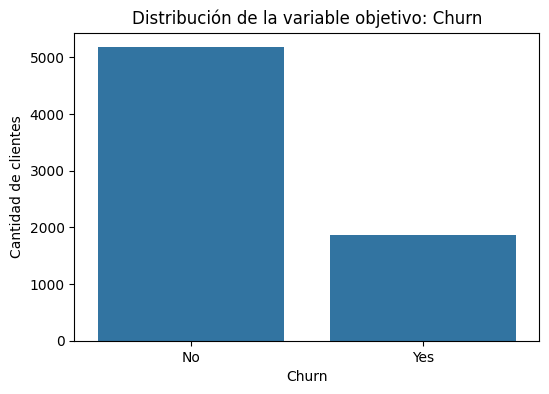

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Distribución de la variable objetivo: Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

La barra de "No" es casi tres veces más alta que la de "Yes". La clase mayoritaria domina claramente, confirmando el desbalance.

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

Al convertir con `errors='coerce'`, las cadenas vacías pasan a ser `NaN`. Esto permite identificar exactamente cuántos registros tienen ese problema.

In [14]:
df["TotalCharges"].isna().sum()

np.int64(11)

Aparecen 11 valores nulos en `TotalCharges`, todos correspondientes a clientes con `tenure = 0`.

In [15]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Los 11 clientes con `TotalCharges` nulo tienen todos `tenure = 0`, es decir, son clientes nuevos que aún no han completado su primer mes. Todos tienen `Churn = 'No'`, lo cual es lógico: no pueden haber abandonado si acaban de entrar. El valor correcto para imputar es 0.

In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Los 11 nulos se reemplazan con 0, representando que estos clientes no tienen cargos totales acumulados todavía.

In [17]:
df["TotalCharges"].isna().sum()

np.int64(0)

Ningún valor nulo en `TotalCharges`. La corrección quedó aplicada correctamente.

In [18]:
target = "Churn"

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

categorical_cols = [col for col in categorical_cols if col not in ["customerID", target]]

print("Variables numéricas:")
print(numeric_cols)

print("\nVariables categóricas:")
print(categorical_cols)

Variables numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Variables categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Se separan 4 variables numéricas (`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`) y 15 categóricas. `customerID` y `Churn` quedan fuera: el primero es identificador y el segundo es la variable objetivo.

In [19]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


`SeniorCitizen` es prácticamente binaria con solo un 16.2% de adultos mayores. `tenure` tiene alta dispersión —de 0 a 72 meses— con mediana en 29. `MonthlyCharges` va de $18.25 a $118.75. `TotalCharges` tiene aún más variabilidad, lo que justifica escalar las variables antes de entrenar los modelos.

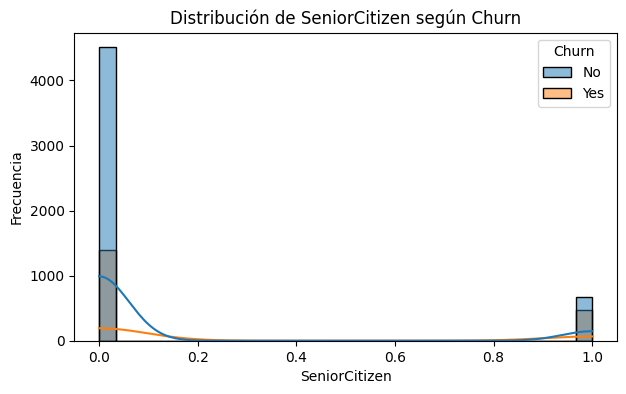

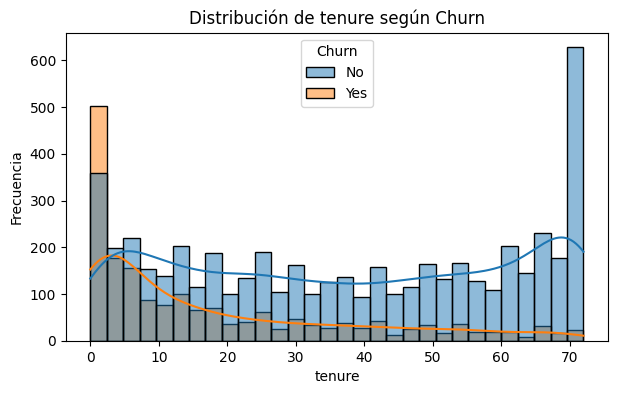

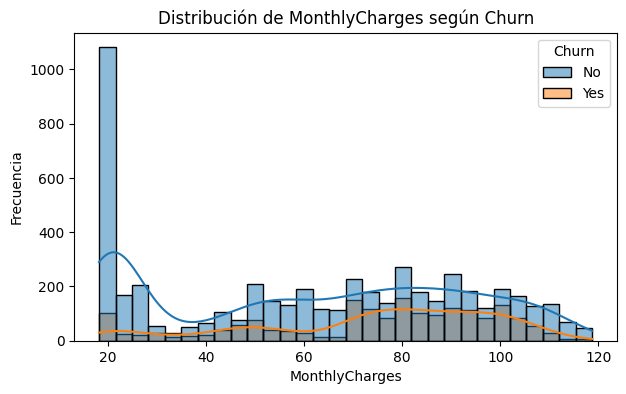

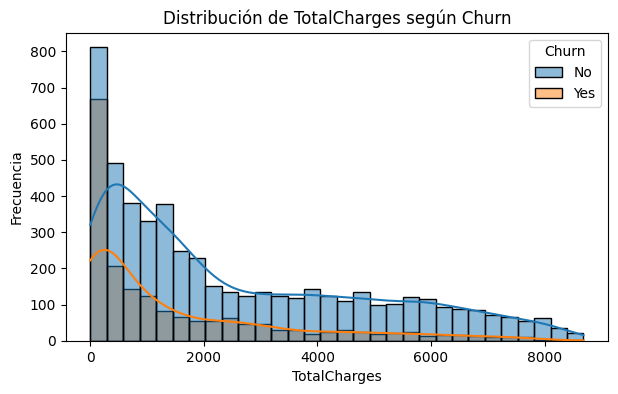

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue="Churn", kde=True, bins=30)
    plt.title(f"Distribución de {col} según Churn")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Los histogramas muestran que los clientes con churn tienden a tener menor `tenure` —la mayoría se concentra en los primeros meses—, `MonthlyCharges` más altos, y `TotalCharges` menores por haber acumulado menos tiempo de facturación. Las diferencias en la distribución entre ambas clases son visibles en las tres variables.

In [21]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
TechSupport
No             

El contrato mensual es el más frecuente con 3.875 clientes. La fibra óptica es el servicio de internet predominante. En servicios adicionales como `OnlineSecurity` y `TechSupport`, la categoría "No" supera ampliamente a "Yes", lo que indica que muchos clientes no los tienen contratados. El pago por cheque electrónico es el método más usado con 2.365 clientes.

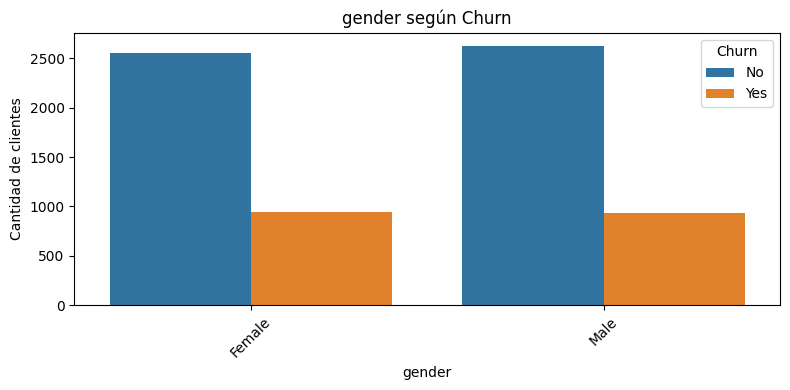

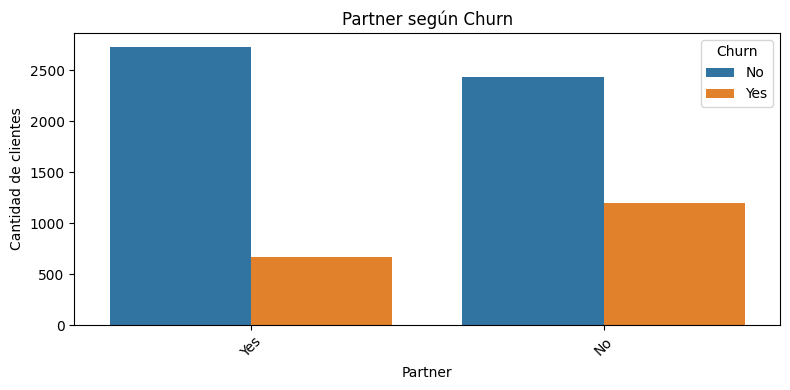

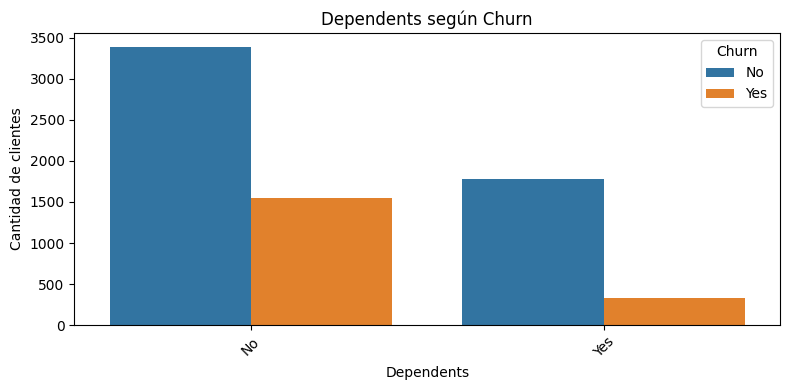

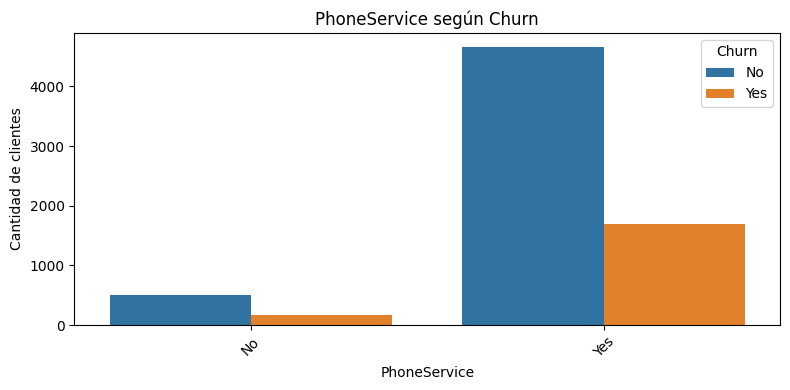

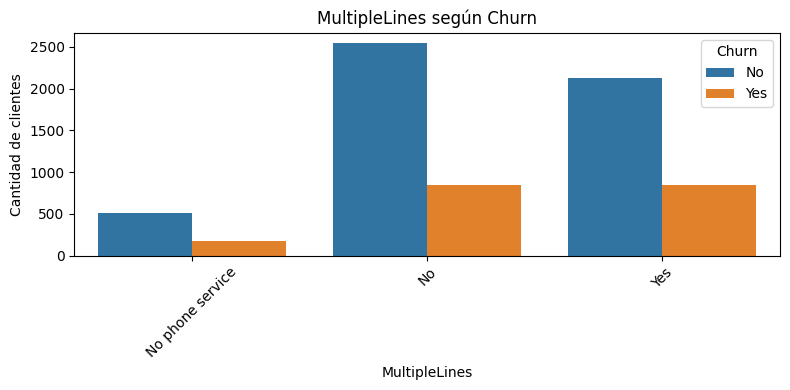

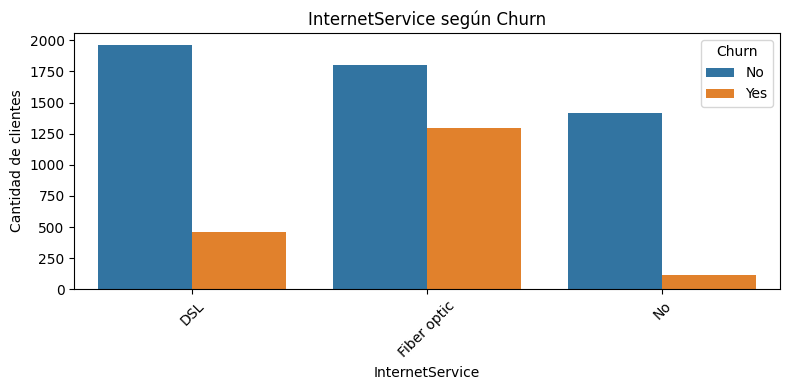

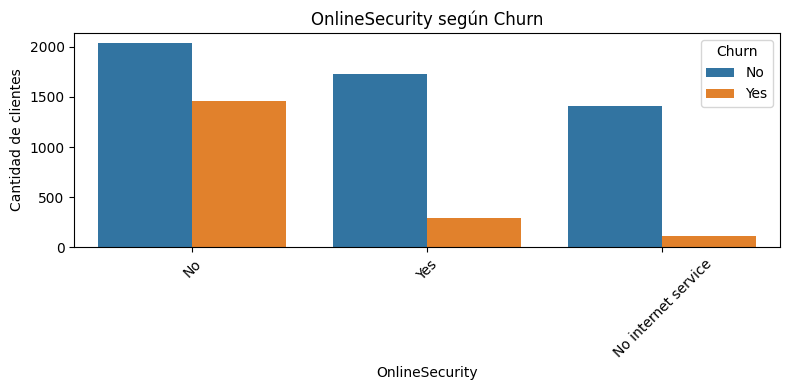

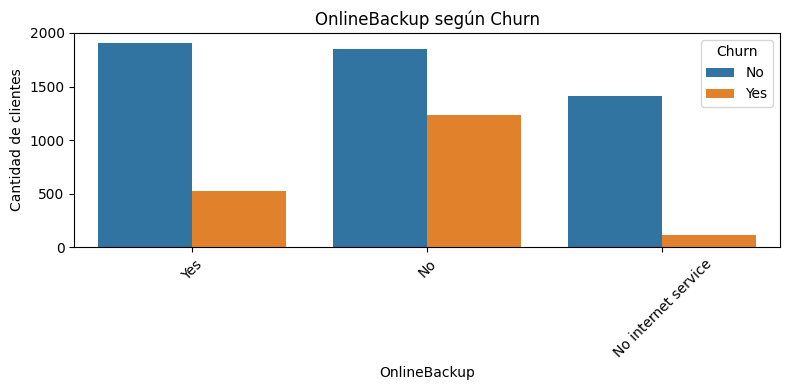

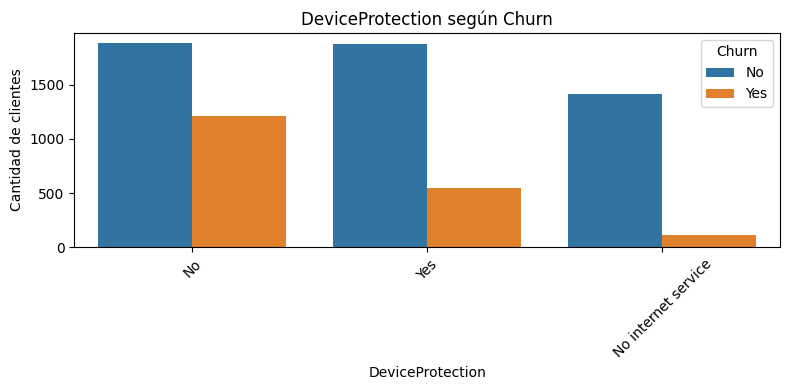

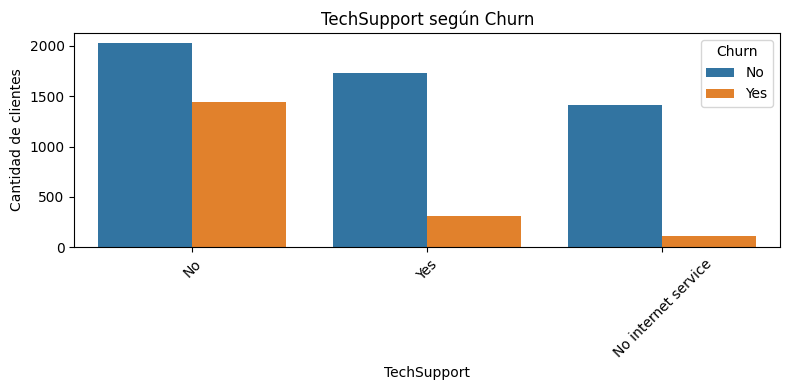

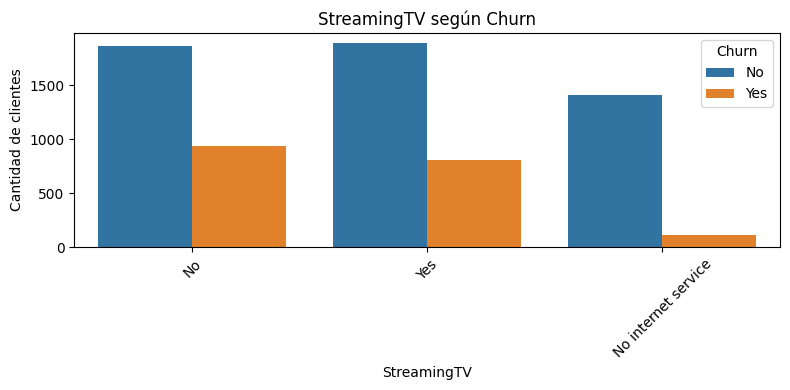

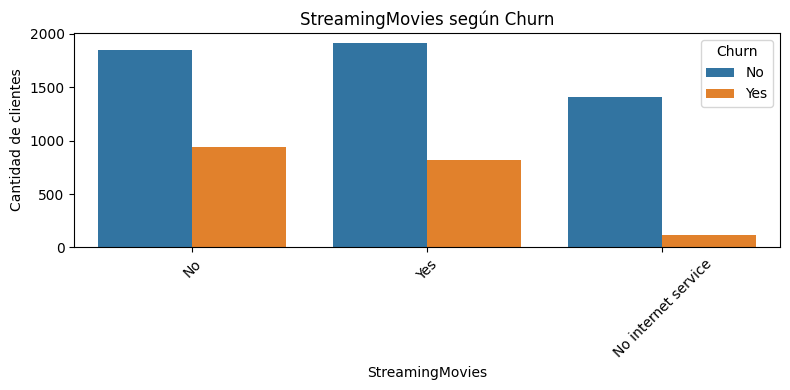

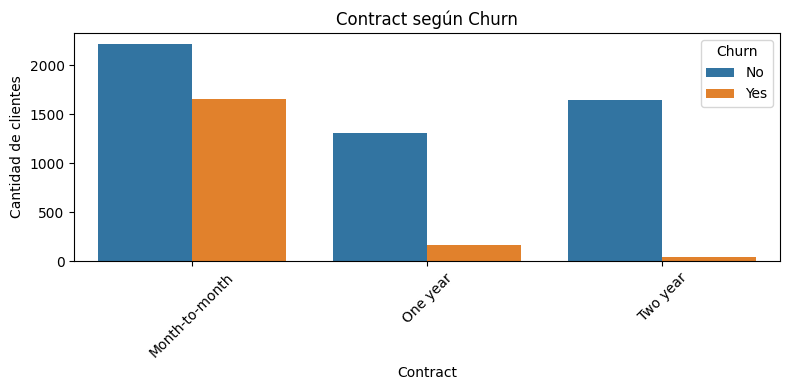

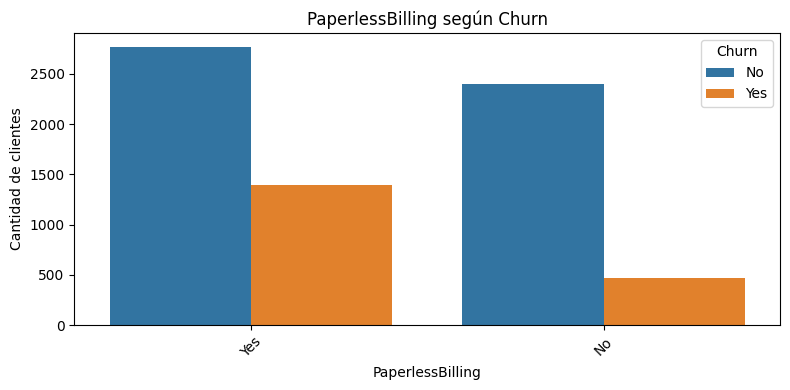

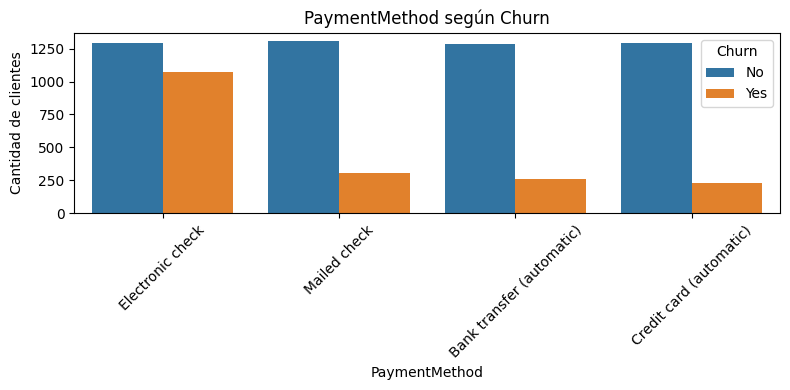

In [22]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} según Churn")
    plt.xlabel(col)
    plt.ylabel("Cantidad de clientes")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Se ve que dentro de `Contract Month-to-month` la barra naranja (churn) es proporcionalmente mucho más alta que en One year o Two year. Para `InternetService`, la fibra óptica tiene claramente más churn que DSL. En `OnlineSecurity` y `TechSupport`, quienes no tienen el servicio muestran una proporción de churn visiblemente mayor.

In [23]:
def churn_rate_by_category(data, column):
    resumen = (
        data.groupby(column)["Churn"]
        .value_counts(normalize=True)
        .rename("proporcion")
        .reset_index()
    )
    
    resumen["porcentaje"] = resumen["proporcion"] * 100
    return resumen

churn_rate_by_category(df, "Contract")

,Contract,Churn,proporcion,porcentaje
0,Month-to-month,No,0.572903,57.290323
1,Month-to-month,Yes,0.427097,42.709677
2,One year,No,0.887305,88.730482
3,One year,Yes,0.112695,11.269518
4,Two year,No,0.971681,97.168142
5,Two year,Yes,0.028319,2.831858


Para `Contract`, el contrato mensual tiene un 42.71% de churn, el anual un 11.27% y el bianual apenas un 2.83%. Es una de las diferencias más grandes entre categorías de todo el dataset.

In [24]:
for col in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling"]:
    print(f"\nTasa de churn por {col}")
    display(churn_rate_by_category(df, col))


Tasa de churn por Contract


,Contract,Churn,proporcion,porcentaje
0,Month-to-month,No,0.572903,57.290323
1,Month-to-month,Yes,0.427097,42.709677
2,One year,No,0.887305,88.730482
3,One year,Yes,0.112695,11.269518
4,Two year,No,0.971681,97.168142
5,Two year,Yes,0.028319,2.831858



Tasa de churn por InternetService


,InternetService,Churn,proporcion,porcentaje
0,DSL,No,0.810409,81.040892
1,DSL,Yes,0.189591,18.959108
2,Fiber optic,No,0.581072,58.107235
3,Fiber optic,Yes,0.418928,41.892765
4,No,No,0.925950,92.595020
5,No,Yes,0.074050,7.404980



Tasa de churn por PaymentMethod


...

,OnlineSecurity,Churn,proporcion,porcentaje
0,No,No,0.582333,58.233276
1,No,Yes,0.417667,41.766724
2,No internet service,No,0.925950,92.595020
3,No internet service,Yes,0.074050,7.404980
4,Yes,No,0.853888,85.388806
5,Yes,Yes,0.146112,14.611194



Tasa de churn por TechSupport


,TechSupport,Churn,proporcion,porcentaje
0,No,No,0.583645,58.364526
1,No,Yes,0.416355,41.635474
2,No internet service,No,0.925950,92.595020
3,No internet service,Yes,0.074050,7.404980
4,Yes,No,0.848337,84.833659
5,Yes,Yes,0.151663,15.166341



Tasa de churn por PaperlessBilling


,PaperlessBilling,Churn,proporcion,porcentaje
0,No,No,0.836699,83.669916
1,No,Yes,0.163301,16.330084
2,Yes,No,0.664349,66.434908
3,Yes,Yes,0.335651,33.565092


Los patrones más llamativos: el pago por cheque electrónico tiene la tasa de churn más alta con 45.29%, seguido del contrato mensual con 42.71%. No tener `OnlineSecurity` ni `TechSupport` está asociado a tasas superiores al 41%. Los clientes con fibra óptica tienen 41.89% de churn, mientras que los que no tienen internet tienen apenas 7.40%.

## Diccionario de variables

Antes de iniciar el análisis exploratorio, se presenta un diccionario de las principales variables del dataset. Esto permite comprender el significado de cada atributo y su posible relación con la variable objetivo `Churn`.

In [26]:
diccionario_variables = pd.DataFrame({
    "Variable": [
        "customerID", "gender", "SeniorCitizen", "Partner", "Dependents",
        "tenure", "PhoneService", "MultipleLines", "InternetService",
        "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling",
        "PaymentMethod", "MonthlyCharges", "TotalCharges", "Churn"
    ],
    "Descripción": [
        "Identificador único del cliente.",
        "Género del cliente.",
        "Indica si el cliente es adulto mayor: 1 = Sí, 0 = No.",
        "Indica si el cliente tiene pareja.",
        "Indica si el cliente tiene dependientes.",
        "Número de meses que el cliente ha permanecido con la empresa.",
        "Indica si el cliente tiene servicio telefónico.",
        "Indica si el cliente tiene múltiples líneas telefónicas.",
        "Tipo de servicio de internet contratado.",
        "Indica si el cliente tiene seguridad en línea.",
        "Indica si el cliente tiene respaldo en línea.",
        "Indica si el cliente tiene protección de dispositivos.",
        "Indica si el cliente tiene soporte técnico.",
        "Indica si el cliente tiene servicio de televisión por streaming.",
        "Indica si el cliente tiene servicio de películas por streaming.",
        "Tipo de contrato del cliente.",
        "Indica si el cliente usa facturación electrónica.",
        "Método de pago utilizado por el cliente.",
        "Cargo mensual del cliente.",
        "Cargo total acumulado del cliente.",
        "Variable objetivo: indica si el cliente abandonó la empresa."
    ],
    "Tipo esperado": [
        "Categórica identificadora", "Categórica", "Numérica binaria", 
        "Categórica", "Categórica", "Numérica", "Categórica", 
        "Categórica", "Categórica", "Categórica", "Categórica", 
        "Categórica", "Categórica", "Categórica", "Categórica", 
        "Categórica", "Categórica", "Categórica", "Numérica", 
        "Numérica", "Categórica objetivo"
    ]
})

diccionario_variables

,Variable,Descripción,Tipo esperado
0,customerID,Identificador único del cliente.,Categórica identificadora
1,gender,Género del cliente.,Categórica
2,SeniorCitizen,"Indica si el cliente es adulto mayor: 1 = Sí, ...",Numérica binaria
3,Partner,Indica si el cliente tiene pareja.,Categórica
4,Dependents,Indica si el cliente tiene dependientes.,Categórica
5,tenure,Número de meses que el cliente ha permanecido ...,Numérica
6,PhoneService,Indica si el cliente tiene servicio telefónico.,Categórica
7,MultipleLines,Indica si el cliente tiene múltiples líneas te...,Categórica
8,InternetService,Tipo de servicio de internet contratado.,Categórica
9,OnlineSecurity,Indica si el cliente tiene seguridad en línea.,Categórica


El diccionario presenta las 21 variables con su descripción y tipo esperado. Se puede ver qué variables son numéricas, cuáles categóricas y cuál es la variable objetivo.

### 5. Análisis de Variables Numéricas

Se analiza la distribución de las cuatro variables numéricas del dataset (`SeniorCitizen`, `tenure`,
`MonthlyCharges`, `TotalCharges`) segmentadas por la variable objetivo `Churn`.

Se utilizan `boxplots` y `histogramas` para visualizar:
- La distribución de cada variable y sus percentiles.
- Las diferencias estadísticas entre clientes con y sin churn.
- La presencia de valores atípicos que pudieran afectar al escalado.

Se anticipan diferencias significativas en `tenure` (antigüedad) y `MonthlyCharges` (cargos mensuales)
entre las dos clases de la variable objetivo.


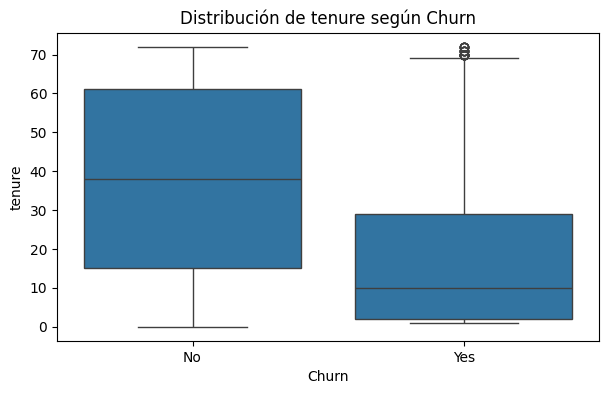

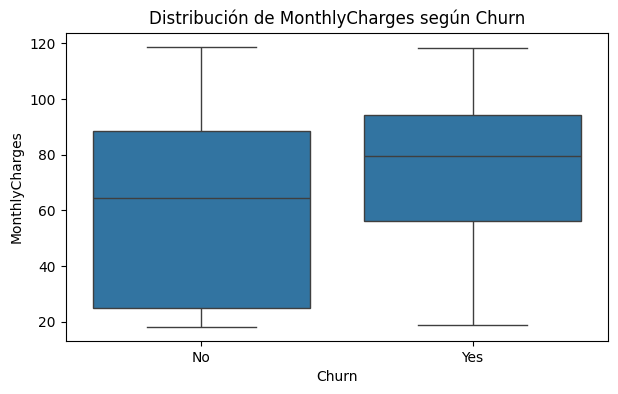

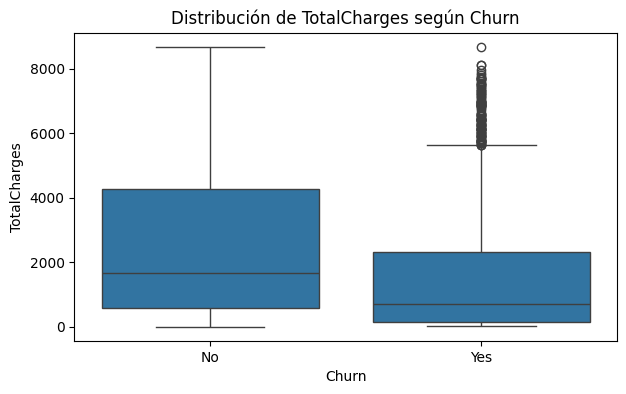

In [30]:
numeric_analysis_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_analysis_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=col)
    
    plt.title(f"Distribución de {col} según Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

En `tenure` la diferencia es muy clara: los clientes con churn tienen mediana de ~10 meses frente a ~38 meses de los que se quedan. En `MonthlyCharges` los que hacen churn tienen medianas más altas (~$79 vs ~$64). `TotalCharges` muestra la diferencia inversa porque los clientes con churn llevan menos tiempo acumulando cargos.

In [31]:
df.groupby("Churn")[numeric_analysis_cols].agg(["mean", "median", "std", "min", "max"]).round(2)

tenure                       MonthlyCharges                       \
        mean median    std min max           mean median    std    min   
Churn                                                                    
No     37.57   38.0  24.11   0  72          61.27  64.43  31.09  18.25   
Yes    17.98   10.0  19.53   1  72          74.44  79.65  24.67  18.85   

              TotalCharges                                    
          max         mean   median      std    min      max  
Churn                                                         
No     118.75      2549.91  1679.52  2329.95   0.00  8672.45  
Yes    118.35      1531.80   703.55  1890.82  18.85  8684.80

Los clientes con churn tienen una antigüedad media de 17.98 meses frente a los 37.57 de los que permanecen —los clientes nuevos son claramente más propensos a abandonar. En cargos mensuales, quienes hacen churn pagan en promedio $74.44 contra $61.27, lo que apunta a que los planes más caros generan más insatisfacción. Los cargos totales son menores para los clientes con churn ($1.531 vs $2.549) precisamente porque llevan menos tiempo en la empresa, no porque paguen menos por mes.

## Tasa de churn por categorías

A continuación se calcula la tasa de churn para las principales variables categóricas. Esta tasa indica el porcentaje de clientes que abandonaron la empresa dentro de cada categoría.

In [32]:
def churn_rate_table(data, column):
    resumen = (
        data.groupby(column)
        .agg(
            clientes=(column, "count"),
            clientes_churn=("Churn", lambda x: (x == "Yes").sum()),
            churn_rate=("Churn", lambda x: (x == "Yes").mean() * 100)
        )
        .reset_index()
        .sort_values("churn_rate", ascending=False)
    )
    
    resumen["churn_rate"] = resumen["churn_rate"].round(2)
    return resumen

La función `churn_rate_table()` devuelve para cada categoría el total de clientes, cuántos hicieron churn y el porcentaje. Las filas se ordenan de mayor a menor tasa de churn para identificar fácilmente los grupos más riesgosos.

In [33]:
variables_categoricas_clave = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "OnlineBackup",
    "DeviceProtection"
]

for col in variables_categoricas_clave:
    print(f"\nTasa de churn por {col}")
    display(churn_rate_table(df, col))


Tasa de churn por Contract


,Contract,clientes,clientes_churn,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83



Tasa de churn por InternetService


,InternetService,clientes,clientes_churn,churn_rate
1,Fiber optic,3096,1297,41.89
0,DSL,2421,459,18.96
2,No,1526,113,7.40



Tasa de churn por PaymentMethod


...

,PaperlessBilling,clientes,clientes_churn,churn_rate
1,Yes,4171,1400,33.57
0,No,2872,469,16.33



Tasa de churn por OnlineBackup


,OnlineBackup,clientes,clientes_churn,churn_rate
0,No,3088,1233,39.93
2,Yes,2429,523,21.53
1,No internet service,1526,113,7.40



Tasa de churn por DeviceProtection


,DeviceProtection,clientes,clientes_churn,churn_rate
0,No,3095,1211,39.13
2,Yes,2422,545,22.50
1,No internet service,1526,113,7.40


Los patrones más destacados en las tablas: `PaymentMethod Electronic check` tiene el mayor churn con 45.29%, `Contract Month-to-month` con 42.71%, y los clientes sin `OnlineSecurity` (41.77%) o sin `TechSupport` (41.64%) también presentan tasas muy altas. En contraste, los clientes sin ningún servicio de internet tienen tasas de apenas 7.40%.

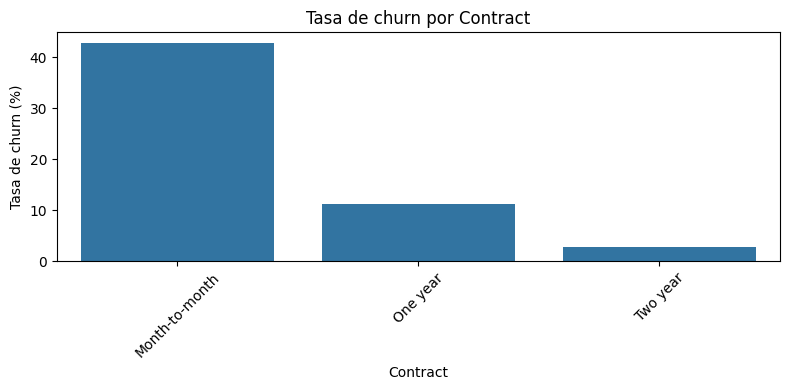

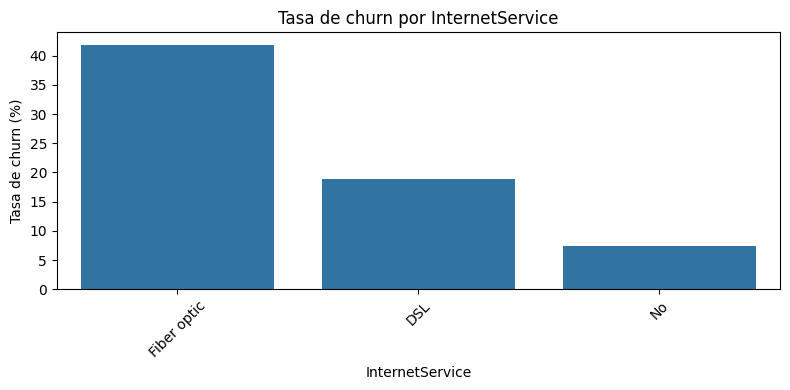

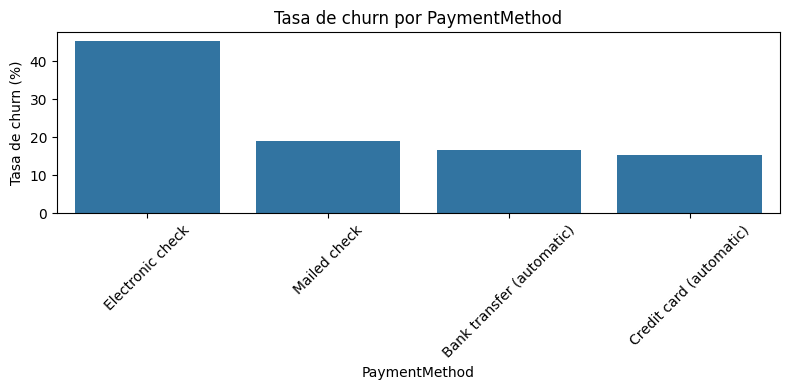

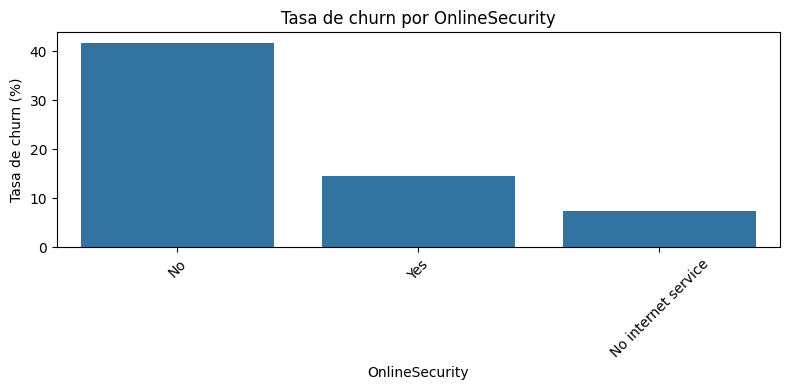

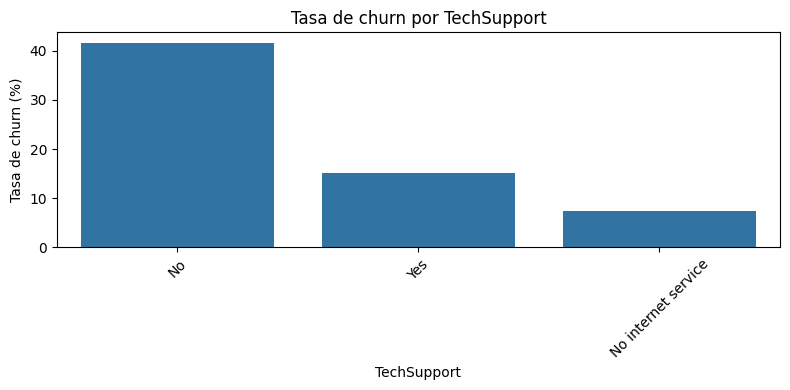

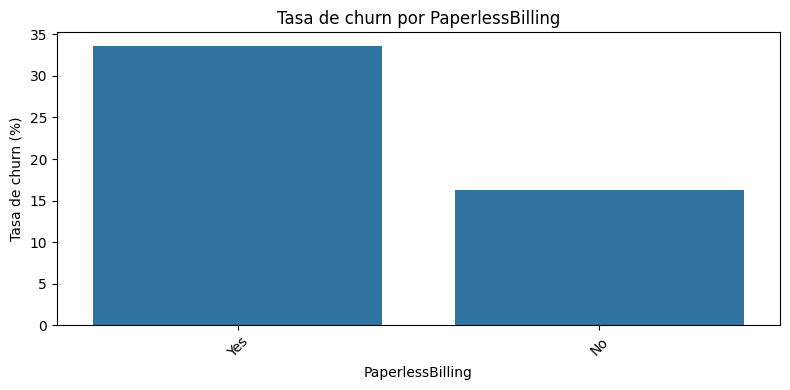

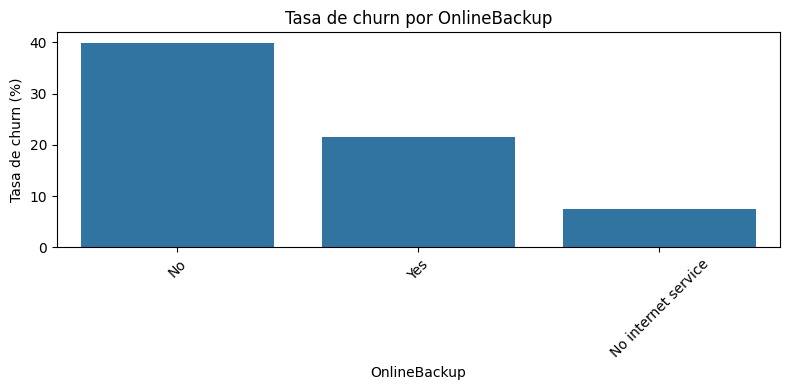

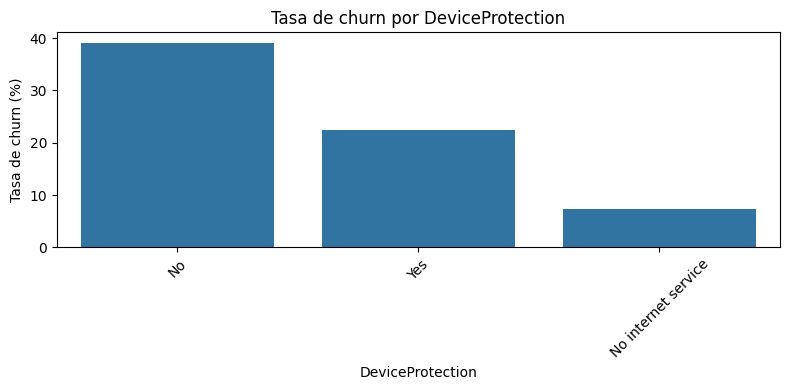

In [34]:
for col in variables_categoricas_clave:
    resumen = churn_rate_table(df, col)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(data=resumen, x=col, y="churn_rate")
    
    plt.title(f"Tasa de churn por {col}")
    plt.xlabel(col)
    plt.ylabel("Tasa de churn (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Los gráficos ordenados de mayor a menor tasa muestran visualmente cuáles categorías son más riesgosas. `Electronic check` en PaymentMethod y `Month-to-month` en Contract sobresalen claramente por encima del resto.

## Análisis cruzado de variables categóricas

Además de analizar cada variable por separado, es útil estudiar combinaciones de variables. En este caso, se analiza la tasa de churn según el tipo de contrato y el método de pago.

In [35]:
tabla_contract_payment = pd.crosstab(
    index=df["Contract"],
    columns=df["PaymentMethod"],
    values=(df["Churn"] == "Yes"),
    aggfunc="mean"
) * 100

tabla_contract_payment = tabla_contract_payment.round(2)

tabla_contract_payment

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,34.13,32.78,53.73,31.58
One year,9.72,10.30,18.44,6.82
Two year,3.37,2.24,7.74,0.79


La combinación más riesgosa es contrato mensual + pago por cheque electrónico, con un 53.73% de churn. En el otro extremo, los contratos bianuales tienen tasas por debajo del 8% sin importar el método de pago.

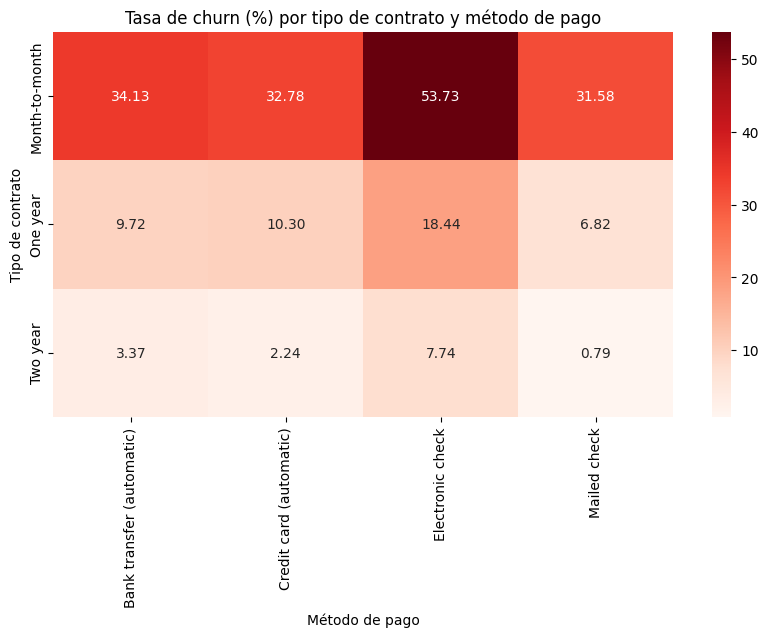

In [36]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    tabla_contract_payment,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Tasa de churn (%) por tipo de contrato y método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Tipo de contrato")
plt.show()

La celda más oscura del mapa es `Month-to-month / Electronic check` (53.73%), confirmando visualmente que es el perfil de mayor riesgo. Los contratos bianuales forman una fila casi completamente blanca en la parte inferior.

In [37]:
tabla_contract_internet = pd.crosstab(
    index=df["Contract"],
    columns=df["InternetService"],
    values=(df["Churn"] == "Yes"),
    aggfunc="mean"
) * 100

tabla_contract_internet = tabla_contract_internet.round(2)

tabla_contract_internet

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.22,54.61,18.89
One year,9.30,19.29,2.47
Two year,1.91,7.23,0.78


La combinación contrato mensual + fibra óptica es la de mayor churn con 54.61%. Los contratos anuales y bianuales reducen drásticamente esa tasa incluso para clientes con fibra óptica.

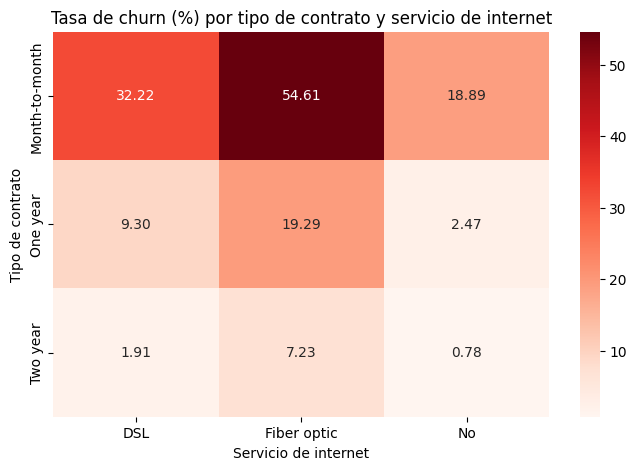

In [38]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla_contract_internet,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Tasa de churn (%) por tipo de contrato y servicio de internet")
plt.xlabel("Servicio de internet")
plt.ylabel("Tipo de contrato")
plt.show()

La celda más oscura es `Month-to-month / Fiber optic` con 54.61%. Los contratos de largo plazo tienen tonos muy claros en todas las columnas, mostrando que el tipo de contrato tiene más influencia que el tipo de internet.

In [39]:
PROCESSED_PATH = BASE_DIR / "data" / "processed" / "telco_churn_clean.csv"

df.to_csv(PROCESSED_PATH, index=False)

print(f"Dataset limpio guardado en: {PROCESSED_PATH}")

Dataset limpio guardado en: c:\Users\sergi\OneDrive\Desktop\Machine Learning\MP3\data\processed\telco_churn_clean.csv


El dataset limpio (con `TotalCharges` corregida a `float64`) se guarda en `data/processed/` para usarse como entrada en el Notebook 2.

## Conclusiones principales del EDA

A partir del análisis exploratorio realizado, se identifican las siguientes conclusiones:

1. El dataset contiene 7.043 clientes y 21 variables, incluyendo información demográfica, servicios contratados, facturación y la variable objetivo `Churn`.

2. La variable objetivo presenta un desbalance moderado: aproximadamente el 73,46% de los clientes no abandonaron la empresa, mientras que el 26,54% sí lo hicieron. Por esta razón, en la etapa de modelado no será suficiente evaluar únicamente el `accuracy`.

3. La variable `tenure` muestra una relación importante con el churn. Los clientes que abandonaron tienen una permanencia promedio menor que los clientes que no abandonaron, lo cual indica que los clientes nuevos o con menor antigüedad pueden representar un grupo de mayor riesgo.

4. Los clientes con contrato mensual presentan una tasa de churn considerablemente más alta que los clientes con contratos de uno o dos años. Esto sugiere que la estabilidad contractual está relacionada con una menor probabilidad de abandono.

5. El método de pago también muestra diferencias relevantes. Los clientes que pagan mediante `Electronic check` presentan una tasa de churn más alta que aquellos que utilizan métodos automáticos como tarjeta de crédito o transferencia bancaria.

6. Las variables relacionadas con servicios adicionales, como `OnlineSecurity`, `TechSupport`, `OnlineBackup` y `DeviceProtection`, muestran diferencias importantes en la tasa de churn. En general, los clientes que no cuentan con estos servicios presentan mayor probabilidad de abandono.

7. Los clientes con servicio de internet por fibra óptica presentan una mayor tasa de churn frente a otros tipos de servicio. Este patrón debe ser analizado con cuidado en el modelado, ya que puede estar relacionado con costos, calidad percibida o características del segmento de clientes.

8. El análisis cruzado entre `Contract`, `PaymentMethod` e `InternetService` permite identificar perfiles específicos de mayor riesgo, especialmente clientes con contrato mensual y ciertos métodos de pago.

9. Para la etapa de modelado será importante usar métricas como `precision`, `recall`, `F1-score` y `AUC`, además de la matriz de confusión y curvas ROC.

10. Las variables identificadas en este EDA servirán como base para construir modelos de clasificación mediante `Pipeline`, `GridSearchCV` y algoritmos como Random Forest, XGBoost, CatBoost y LightGBM.